# Семинар 13. Обучение с подкреплением (RL) — практика

Адаптация ноутбука с пары под другую среду: `SuperMarioBros2-v0` (The Lost Levels) с расширенным набором действий `COMPLEX_MOVEMENT`.

In [1]:
# Установка необходимых версий для верного воспроизведения
# При работе в Colab возможно понадобится перезапуск среды, при повторной инсталляции numpy
# При работе в Colab обязательно выберите: Среда выполнения -> GPU -> Версия 2026.04
!pip uninstall gym-super-mario-bros nes-py -y
!pip install -q gym-super-mario-bros==7.3.0 nes-py==8.2.1
!pip install 'numpy<2.0.0'
!pip install -q stable-baselines3
!pip install 'shimmy>=2.0'

Found existing installation: gym-super-mario-bros 7.3.0
Uninstalling gym-super-mario-bros-7.3.0:
  Successfully uninstalled gym-super-mario-bros-7.3.0
Found existing installation: nes_py 8.2.1
Uninstalling nes_py-8.2.1:
  Successfully uninstalled nes_py-8.2.1


## 1. Курс молодого бойца

Основные определения:

1. **Среда (Environment)** — мир, с которым агент взаимодействует.
2. **Действие (Action)** $a \in \mathcal{A}$ — выбор агента.
3. **Состояние (State)** $s \in \mathcal{S}$ — текущая характеристика среды.
4. **Награда (Reward)** $r: \mathcal{S} \times \mathcal{A} \to \mathbb{R}$ — сигнал обратной связи.
5. **Политика** $\pi(a|s)$ — распределение вероятностей действий при условии состояния.

$$R = \mathbb{E}\left[\sum_{t=0}^{\infty} \gamma^t r_t\right]$$

In [2]:
# Импортируем игру
import gym_super_mario_bros
# Импортируем Joypad пространство (пространство с уменьшенным кол-вом состояний)
from nes_py.wrappers import JoypadSpace
# Расширенное пространство действий
from gym_super_mario_bros.actions import COMPLEX_MOVEMENT
import gym

# Для нормально рендеринга в Colab
from gym.wrappers import RecordVideo
from IPython.display import Video
import shutil
import glob
import time

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Среда

Создаём среду `SuperMarioBros2-v0` (The Lost Levels) и оборачиваем её в `COMPLEX_MOVEMENT` — 12 действий вместо 7 в `SIMPLE_MOVEMENT`.

In [3]:
env = gym_super_mario_bros.make('SuperMarioBros2-v0')
env = JoypadSpace(env, COMPLEX_MOVEMENT)
print('Action space:', env.action_space)
print('Observation space:', env.observation_space)

/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment SuperMarioBros2-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(


Action space: Discrete(12)
Observation space: Box(0, 255, (240, 256, 3), uint8)


/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [4]:
# Сэмплируем случайное действие
action = env.action_space.sample()
print('Sampled action index:', action, '->', COMPLEX_MOVEMENT[action])

Sampled action index: 10 -> ['down']


In [5]:
# Запускаем 1000 случайных шагов
env = gym_super_mario_bros.make('SuperMarioBros2-v0')
env = JoypadSpace(env, COMPLEX_MOVEMENT)

done = True
total_reward = 0.0
for _ in range(1000):
    if done:
        env.reset()
    action = env.action_space.sample()
    state, reward, done, info = env.step(action)
    total_reward += reward
env.close()
print('Total reward over 1000 random steps:', total_reward)

/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:227: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(done, (bool, np.bool8)):


Total reward over 1000 random steps: -71.0


In [6]:
# Видео случайной политики
shutil.rmtree('./video', ignore_errors=True)

env = gym_super_mario_bros.make('SuperMarioBros2-v0')
env = JoypadSpace(env, COMPLEX_MOVEMENT)
env = RecordVideo(env, './video', episode_trigger=lambda x: True)

done = False
steps = 0
max_steps = 500

state = env.reset()
while not done and steps < max_steps:
    action = env.action_space.sample()
    state, reward, done, info = env.step(action)
    steps += 1

if hasattr(env, 'video_recorder'):
    recorder = env.video_recorder
    if recorder is not None:
        recorder.close()

time.sleep(2)

/usr/local/lib/python3.12/dist-packages/gym/wrappers/monitoring/video_recorder.py:67: DeprecationWarning: WARN: `env.metadata["render.modes"] is marked as deprecated and will be replaced with `env.metadata["render_modes"]` see https://github.com/openai/gym/pull/2654 for more details
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/monitoring/video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment SuperMarioBros2-v0 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/monitoring/video_recorder.py:149: DeprecationWarning: WARN: `env.metadata["video.frames_per_second"] is marked as deprecated and will be replaced with `env.metadata["render_fps"]` see https://github.com/openai/gym/pull/2654 for more details
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument m

In [7]:
from IPython.display import Video, display
video_files = sorted(glob.glob('./video/*.mp4'))
print(video_files)
if video_files:
    display(Video(video_files[-1], embed=True, width=640))

['./video/rl-video-episode-0.mp4']


## 3. Предобработка среды (Wrappers)

Сжимаем наблюдение, чтобы CNN видела только полезный сигнал:

1. `GrayScaleObservation` — RGB → 1 канал.
2. `SB3Compat` — починка несовместимости старого API gym и stable‑baselines3.
3. `DummyVecEnv` — оборачивает в vec‑env.
4. `VecFrameStack` — склеивает 4 последовательных кадра, чтобы агент видел движение.

In [8]:
from gym.wrappers import FrameStack, GrayScaleObservation
from stable_baselines3.common.vec_env import VecFrameStack, DummyVecEnv
from matplotlib import pyplot as plt

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# Compatibility wrapper между gym и stable-baselines3
class SB3Compat(gym.Wrapper):
    def reset(self, **kwargs):
        kwargs.pop('seed', None)
        kwargs.pop('options', None)
        obs = self.env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]
        return obs, {}

    def step(self, action):
        result = self.env.step(action)
        if len(result) == 4:
            obs, reward, done, info = result
            terminated = done
            truncated = False
            return obs, reward, terminated, truncated, info
        return result

In [10]:
# Полный pipeline
env = gym_super_mario_bros.make('SuperMarioBros2-v0')
env = JoypadSpace(env, COMPLEX_MOVEMENT)
env = GrayScaleObservation(env, keep_dim=True)
env = SB3Compat(env)
env = DummyVecEnv([lambda: env])
env = VecFrameStack(env, 4, channels_order='last')

/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment SuperMarioBros2-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium envi

Shape: (240, 256, 4)


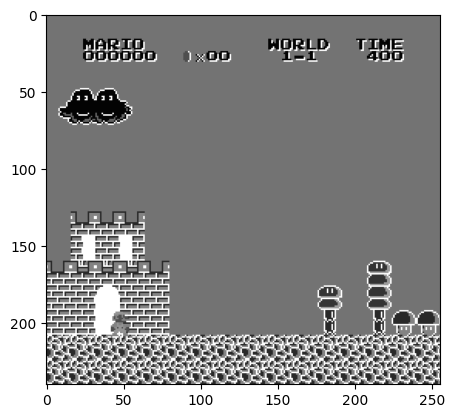

In [11]:
state = env.reset()
print('Shape:', state[0].shape)
plt.imshow(state[0])
plt.show()

## 4. Обучение PPO

**PPO (Proximal Policy Optimization)** — стабильный policy‑gradient метод с клиппированием шага обновления:

$$r_t(\theta) = \frac{\pi_{\theta}(a_t \mid s_t)}{\pi_{\theta_{\text{old}}}(a_t \mid s_t)}$$

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t \left[ \min \left( r_t(\theta) A_t, \ \text{clip}(r_t(\theta), 1 - \epsilon, 1 + \epsilon) A_t \right) \right]$$

Политикой будет `CnnPolicy` — стандартная CNN из 3 свёрток + 2 полносвязных слоёв.

In [12]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback

CHECKPOINT_DIR = './train/'
LOG_DIR = './logs/'

class TrainAndLoggingCallback(BaseCallback):
    def __init__(self, check_freq, save_path, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(self.save_path, f'best_model_{self.n_calls}')
            print(model_path)
            self.model.save(model_path)
        return True

callback = TrainAndLoggingCallback(check_freq=10000, save_path=CHECKPOINT_DIR)

In [13]:
model = PPO(
    'CnnPolicy',
    env,
    verbose=1,
    tensorboard_log=LOG_DIR,
    learning_rate=1e-5,
    n_steps=512,
)

Using cuda device
Wrapping the env in a VecTransposeImage.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:

model.learn(total_timesteps=30000, callback=callback)

Logging to ./logs/PPO_1


/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:227: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(done, (bool, np.bool8)):


----------------------------
| time/              |     |
|    fps             | 111 |
|    iterations      | 1   |
|    time_elapsed    | 4   |
|    total_timesteps | 512 |
----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 93            |
|    iterations           | 2             |
|    time_elapsed         | 10            |
|    total_timesteps      | 1024          |
| train/                  |               |
|    approx_kl            | 0.00038295344 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -2.48         |
|    explained_variance   | 0.00308       |
|    learning_rate        | 1e-05         |
|    loss                 | 4.64          |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00185      |
|    value_loss           | 12.6          |
-------------------------------------------
-----

/usr/local/lib/python3.12/dist-packages/gym_super_mario_bros/smb_env.py:148: RuntimeWarning: overflow encountered in scalar subtract
  return (self.ram[0x86] - self.ram[0x071c]) % 256


------------------------------------------
| time/                   |              |
|    fps                  | 90           |
|    iterations           | 4            |
|    time_elapsed         | 22           |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0012854377 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.48        |
|    explained_variance   | 0.0168       |
|    learning_rate        | 1e-05        |
|    loss                 | 4.5          |
|    n_updates            | 30           |
|    policy_gradient_loss | -0.00372     |
|    value_loss           | 7.19         |
------------------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 89           |
|    iterations           | 5            |
|    time_elapsed         | 28           |
|    total_

In [15]:
model.save('mario_lost_levels_ppo')

## 5. Финальный тест

In [16]:
model = PPO.load('mario_lost_levels_ppo')

env = gym_super_mario_bros.make('SuperMarioBros2-v0')
env = JoypadSpace(env, COMPLEX_MOVEMENT)
env = GrayScaleObservation(env, keep_dim=True)
env = SB3Compat(env)
env = DummyVecEnv([lambda: env])
env = VecFrameStack(env, 4, channels_order='last')

state = env.reset()
print('predict ->', model.predict(state)[0])

/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment SuperMarioBros2-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(


predict -> [11]


/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [1]:

shutil.rmtree('./video_trained', ignore_errors=True)

rec_env = gym_super_mario_bros.make('SuperMarioBros2-v0')
rec_env = JoypadSpace(rec_env, COMPLEX_MOVEMENT)
rec_env = RecordVideo(rec_env, './video_trained', episode_trigger=lambda x: True)

wrapped = GrayScaleObservation(rec_env, keep_dim=True)
wrapped = SB3Compat(wrapped)
wrapped = DummyVecEnv([lambda: wrapped])
wrapped = VecFrameStack(wrapped, 4, channels_order='last')

state = wrapped.reset()
steps = 0
max_steps = 2000
while steps < max_steps:
    action, _ = model.predict(state)
    state, reward, done, info = wrapped.step(action)
    steps += 1
    if done.any():
        break

# Финализируем mp4 вручную через RecordVideo
if hasattr(rec_env, 'video_recorder') and rec_env.video_recorder is not None:
    rec_env.video_recorder.close()

time.sleep(2)

trained_videos = sorted(glob.glob('./video_trained/*.mp4'))
print(trained_videos)
if trained_videos:
    display(Video(trained_videos[-1], embed=True, width=640))

NameError: name 'shutil' is not defined